# ARIMA and SARIMA

Fits statistical time-series models (proposal.txt Sections 10.2-10.3) on the univariate demand series from `data/processed/demand_clean.csv`, using the same chronological 70/15/15 split as the baseline notebook. SARIMA's seasonal order captures the dominant daily (24-hour) demand cycle; a seasonal period of 168 (weekly) is computationally impractical for SARIMAX at hourly resolution, so weekly patterns are instead captured via the lag/calendar features used by the ML and DL notebooks.

In [1]:
import sys
from pathlib import Path

import yaml

# Works both in the local repo and on Kaggle. Locally, config.yaml is read
# from disk. On Kaggle there is no repo checkout -- only whatever cells you
# paste -- so the config is built inline instead, pointed at the attached
# dataset under /kaggle/input.
IS_KAGGLE = Path("/kaggle/input/datasets/uom230425m/time-series-project").exists()

if IS_KAGGLE:
    import os

    available = os.listdir("/kaggle/input/datasets/uom230425m/time-series-project")
    print("Kaggle input datasets found:", available)
    if len(available) != 1:
        raise RuntimeError(
            "Expected exactly one dataset under /kaggle/input/datasets/uom230425m/time-series-project -- set "
            "KAGGLE_DATASET_DIR manually to the one containing "
            "energy_dataset.csv and weather_features.csv."
        )
    KAGGLE_DATASET_DIR = Path("/kaggle/input/datasets/uom230425m/time-series-project") / available[0]

    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {
            "raw_path": str(KAGGLE_DATASET_DIR),
            "processed_path": "/kaggle/working/data/processed",
            "processed_file": "/kaggle/working/data/processed/demand_clean.csv",
            "timestamp_col": "timestamp",
            "target_col": "demand",
            "frequency": "h",
        },
        "split": {"train_ratio": 0.70, "val_ratio": 0.15, "test_ratio": 0.15},
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

Kaggle input datasets found: ['load_forecasting_dataset_corrected.csv']


{'data': {'raw_path': '/kaggle/input/datasets/uom230425m/time-series-project/load_forecasting_dataset_corrected.csv',
  'processed_path': '/kaggle/working/data/processed',
  'processed_file': '/kaggle/working/data/processed/demand_clean.csv',
  'timestamp_col': 'timestamp',
  'target_col': 'demand',
  'frequency': 'h'},
 'split': {'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15}}

In [2]:
import pandas as pd

# On Kaggle, src/ isn't on disk (only pasted cells are) -- these are
# identical inline copies of src/data/load_data.py, src/models/statistical.py,
# src/evaluation/metrics.py, and src/visualization/plots.py.
# Keep them in sync with src/ if that logic ever changes.
if IS_KAGGLE:
    import matplotlib.pyplot as plt
    import numpy as np
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    def load_raw_data(path, timestamp_col="timestamp"):
        df = pd.read_csv(path, parse_dates=[timestamp_col])
        return df.sort_values(timestamp_col).reset_index(drop=True)

    def set_timestamp_index(df, timestamp_col="timestamp"):
        df = df.set_index(timestamp_col)
        return df.sort_index()

    def chronological_split(df, train_ratio, val_ratio):
        n = len(df)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        return df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]

    def fit_arima(series, order):
        return ARIMA(series, order=order).fit()

    def fit_sarima(series, order, seasonal_order):
        return SARIMAX(series, order=order, seasonal_order=seasonal_order).fit(disp=False)

    def mae(y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    def mape(y_true, y_pred):
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    def smape(y_true, y_pred):
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2
        return np.mean(np.abs(y_true - y_pred) / denom) * 100

    def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(y_true.index, y_true.values, label="Actual")
        ax.plot(y_pred.index, y_pred.values, label="Predicted", alpha=0.8)
        ax.set_title(title)
        ax.legend()
        return fig

    def plot_residuals(y_true, y_pred, title="Residuals"):
        residuals = y_true - y_pred
        fig, ax = plt.subplots(figsize=(12, 3))
        ax.plot(residuals.index, residuals.values)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(title)
        return fig
else:
    from src.data.load_data import chronological_split, load_raw_data, set_timestamp_index
    from src.evaluation.metrics import mae, mape, rmse, smape
    from src.models.statistical import fit_arima, fit_sarima
    from src.visualization.plots import plot_actual_vs_predicted, plot_residuals

PROCESSED_PATH = REPO_ROOT / config["data"]["processed_file"]
TIMESTAMP_COL = config["data"]["timestamp_col"]
TARGET_COL = config["data"]["target_col"]
TRAIN_RATIO = config["split"]["train_ratio"]
VAL_RATIO = config["split"]["val_ratio"]

## Load data and chronological split

In [3]:
df = load_raw_data(PROCESSED_PATH, TIMESTAMP_COL)
df = set_timestamp_index(df, TIMESTAMP_COL)

train_df, val_df, test_df = chronological_split(df, TRAIN_RATIO, VAL_RATIO)
print(f"Train: {train_df.index.min()} -> {train_df.index.max()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index.min()} -> {val_df.index.max()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index.min()} -> {test_df.index.max()} ({len(test_df)} rows)")

# Fit on everything up to the test period (train + val), forecast the test horizon.
history = pd.concat([train_df, val_df])[TARGET_COL]

Train: 2020-01-01 00:00:00 -> 2023-10-16 13:00:00 (33230 rows)
Val:   2023-10-16 14:00:00 -> 2024-08-08 06:00:00 (7121 rows)
Test:  2024-08-08 07:00:00 -> 2025-05-31 23:00:00 (7121 rows)


## Fit ARIMA

In [4]:
ARIMA_ORDER = (2, 1, 2)

arima_model = fit_arima(history, order=ARIMA_ORDER)
arima_forecast = arima_model.forecast(steps=len(test_df))
arima_forecast.index = test_df.index
print(arima_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                40351
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -243132.441
Date:                Wed, 05 Aug 2026   AIC                         486274.882
Time:                        11:50:14   BIC                         486317.909
Sample:                    01-01-2020   HQIC                        486288.495
                         - 08-08-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9892      0.014    -72.242      0.000      -1.016      -0.962
ar.L2          0.0054      0.005      1.071      0.284      -0.004       0.015
ma.L1         -0.0058      0.013     -0.457      0.6

## Fit SARIMA

Seasonal order `(1, 1, 1, 24)` captures the daily demand cycle. Fitting on ~26k hourly observations with a seasonal term can take several minutes.

In [5]:
SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 24)

sarima_model = fit_sarima(history, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER)
sarima_forecast = sarima_model.forecast(steps=len(test_df))
sarima_forecast.index = test_df.index
print(sarima_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                40351
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood             -243571.035
Date:                            Wed, 05 Aug 2026   AIC                         487152.071
Time:                                    11:55:19   BIC                         487195.094
Sample:                                01-01-2020   HQIC                        487165.684
                                     - 08-08-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0201      0.006      3.185      0.001       0.008       0.033
ma.L1         -0.9999      0.000  -

## Evaluate on the test set

In [6]:
y_test = test_df[TARGET_COL]

results_df = pd.DataFrame([
    {
        "model": "ARIMA(2,1,2)",
        "mae": mae(y_test, arima_forecast),
        "rmse": rmse(y_test, arima_forecast),
        "mape": mape(y_test, arima_forecast),
        "smape": smape(y_test, arima_forecast),
    },
    {
        "model": "SARIMA(1,1,1)(1,1,1,24)",
        "mae": mae(y_test, sarima_forecast),
        "rmse": rmse(y_test, sarima_forecast),
        "mape": mape(y_test, sarima_forecast),
        "smape": smape(y_test, sarima_forecast),
    },
]).sort_values("rmse").reset_index(drop=True)
results_df

,model,mae,rmse,mape,smape
0,"ARIMA(2,1,2)",79.858485,100.367732,5.377375,5.33766
1,"SARIMA(1,1,1)(1,1,1,24)",79.884893,100.398967,5.378198,5.33942


## Visualize forecasts

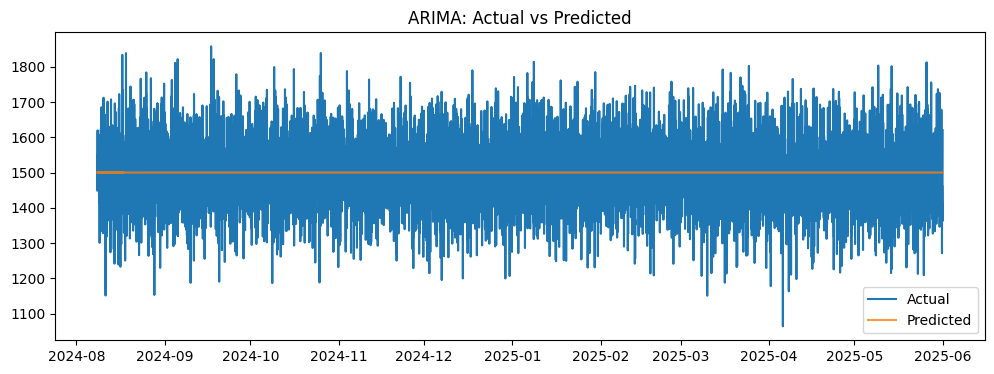

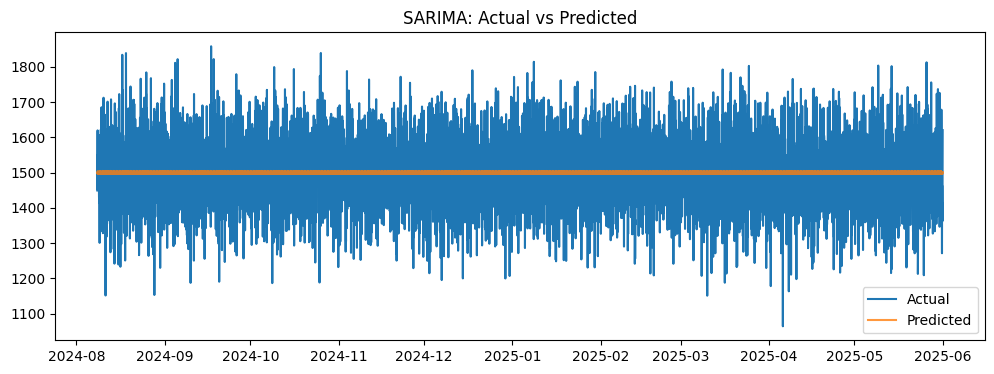

In [7]:
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig = plot_actual_vs_predicted(y_test, arima_forecast, title="ARIMA: Actual vs Predicted")
fig.savefig(FIGURES_DIR / "arima_forecast.png", dpi=150, bbox_inches="tight")

fig = plot_actual_vs_predicted(y_test, sarima_forecast, title="SARIMA: Actual vs Predicted")
fig.savefig(FIGURES_DIR / "sarima_forecast.png", dpi=150, bbox_inches="tight")

## Residual diagnostics

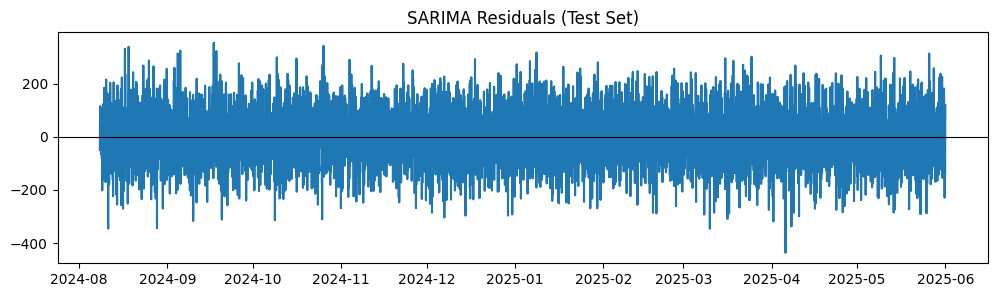

In [8]:
fig = plot_residuals(y_test, sarima_forecast, title="SARIMA Residuals (Test Set)")
fig.savefig(FIGURES_DIR / "sarima_residuals.png", dpi=150, bbox_inches="tight")

## Save results

In [9]:
RESULTS_PATH = REPO_ROOT / "reports" / "statistical_metrics.csv"
results_df.to_csv(RESULTS_PATH, index=False)
print(f"Saved statistical model results to {RESULTS_PATH}")

Saved statistical model results to /kaggle/working/reports/statistical_metrics.csv


## Save predictions for cross-notebook comparison

Used by `10_model_comparison.ipynb` to overlay forecasts and run Diebold-Mariano significance tests across all model families.

In [10]:
predictions_df = pd.concat([
    pd.DataFrame({
        "timestamp": y_test.index, "actual": y_test.values,
        "predicted": arima_forecast.values, "model": "ARIMA(2,1,2)",
    }),
    pd.DataFrame({
        "timestamp": y_test.index, "actual": y_test.values,
        "predicted": sarima_forecast.values, "model": "SARIMA(1,1,1)(1,1,1,24)",
    }),
], ignore_index=True)

PREDICTIONS_PATH = REPO_ROOT / "reports" / "statistical_predictions.csv"
predictions_df.to_csv(PREDICTIONS_PATH, index=False)
print(f"Saved {len(predictions_df)} prediction rows to {PREDICTIONS_PATH}")

Saved 14242 prediction rows to /kaggle/working/reports/statistical_predictions.csv
